# ***Generative AI Business Analyst Assistant using Google Gemini***

# *Project Overview*

*Developed an AI-powered Business Analyst Assistant using Gemini and Python to analyze Superstore sales data through natural-language queries. Implemented AI-based question understanding, Pandas-driven data analysis, automated business responses, Plotly visualizations, and a continuous interactive chatbot.*

# *Project Objectives*

* *Develop an AI-powered Business Analyst Assistant using* ***Gemini and Python***.
* *Enable* ***natural-language querying*** *of Superstore sales data*.
* *Perform data analysis using* ***Pandas*** *for sales, profit, quantity, discount, and business metrics.*
* *Support* ***total, average, minimum, maximum, grouping, top-N, and bottom-N*** *analysis*.
* *Generate* ***automated Plotly visualizations*** *and business insights*.
* *Provide a* ***continuous interactive chatbot*** *for multiple queries.*


# *Dataset Description*

*The project uses the* ***Superstore Sales Dataset***, *which contains* ***9,994 records and 21 columns*** *related to sales transactions. It includes information about orders, customers, products, categories, regions, shipping, sales, quantity, discounts, and profit. The dataset is used to perform* ***business analysis, identify sales and profit trends, and provide insights through the AI Business Analyst Assistant***.


In [ ]:
# Install Required Libraries
!pip install -q pandas numpy matplotlib seaborn plotly google-genai

In [ ]:
import os
import json
import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from google import genai
from IPython.display import display

In [ ]:
# Load the Dataset
df=pd.read_csv("/content/drive/MyDrive/AI Business Analyst Assistant/archive/Sample - Superstore.csv", encoding="latin-1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9994, 21)


In [ ]:
# Display the first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Display the number of rows and columns in the dataset
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 9994
Number of Columns: 21


In [ ]:
# Display all column names in the dataset
print("Columns in the dataset:\n")

for column in df.columns:
    print(column)

Columns in the dataset:

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [ ]:
# Display dataset information and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
# Generate descriptive statistics for numerical columns
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
# Calculate the percentage of missing values in each column
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

,0
Row ID,0.0
Order ID,0.0
Order Date,0.0
Ship Date,0.0
Ship Mode,0.0
Customer ID,0.0
Customer Name,0.0
Segment,0.0
Country,0.0
City,0.0


In [ ]:
# Check for duplicate rows in the dataset
print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 0


In [ ]:
# Convert Order Date and Ship Date columns to datetime format
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    errors="coerce"
)

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [ ]:
# Convert key numerical columns to numeric data types for analysis
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df[numeric_columns].dtypes)

Sales       float64
Quantity      int64
Discount    float64
Profit      float64
dtype: object


In [ ]:
# Verify missing values after data preprocessing
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
# Display the final dataset information and key categorical values
print("FINAL DATASET INFORMATION")
print("=" * 40)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategories:")
print(df["Category"].unique())

print("\nRegions:")
print(df["Region"].unique())

print("\nSegments:")
print(df["Segment"].unique())

FINAL DATASET INFORMATION
Rows: 9994
Columns: 21

Numeric Columns:
['Sales', 'Quantity', 'Discount', 'Profit']

Categories:
['Furniture' 'Office Supplies' 'Technology']

Regions:
['South' 'West' 'Central' 'East']

Segments:
['Consumer' 'Corporate' 'Home Office']


In [ ]:
# Calculate total sales by product category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


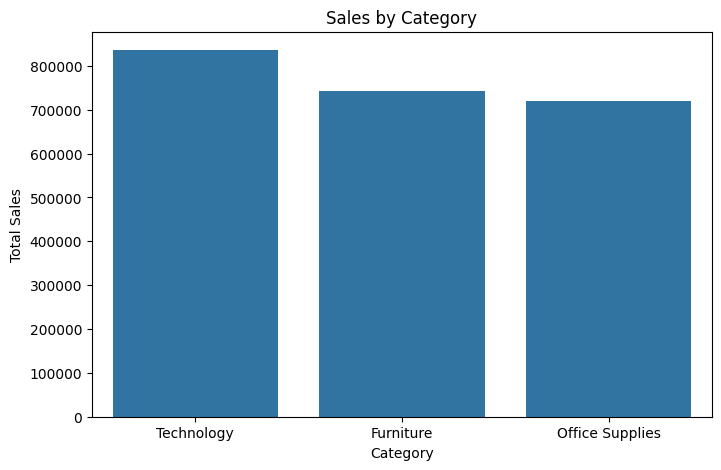

In [ ]:
# Visualize total sales by category using a bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

## **Analysis**

*The Sales by Category graph shows that Technology has the highest total sales, at approximately* $835,000. Furniture follows with around $745,000, *while Office Supplies has the lowest sales at approximately* $720,000. *Overall, sales are relatively well distributed across the three categories, with Technology performing slightly better than the others.*

In [ ]:
# Calculate total profit by product category
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


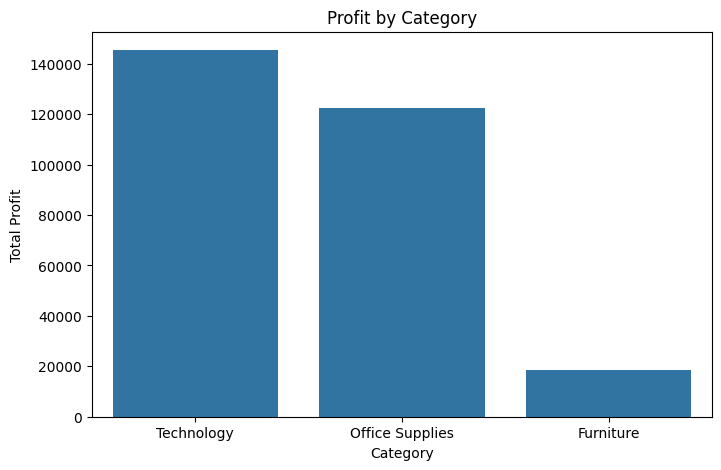

In [ ]:
# Visualize total profit by category using a bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

## **Analysis**

*The Profit by Category graph shows that Technology generates the highest total profit, at approximately* $145,000. *Office Supplies is second with around* $123,000, *while Furniture has the lowest profit at only about* $18,000. *Although Furniture has strong sales, its profit is significantly lower, indicating that its costs or discounts may be reducing profitability.*

In [ ]:
# Calculate total sales by region
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


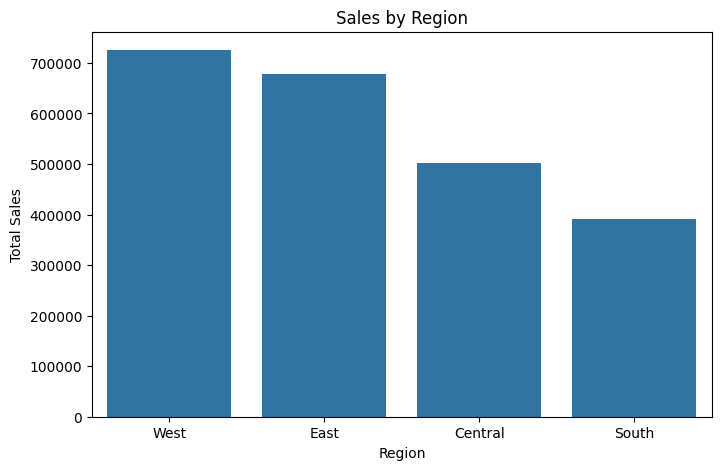

In [ ]:
# Visualize total sales by region using a bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

## **Analysis**

The **Sales by Region** graph shows that the **West region** has the highest total sales, at approximately **$725,000**, followed by the **East region** with around **$680,000**. The **Central region** generates about **$500,000**, while the **South region** has the lowest sales at approximately **$390,000**. Overall, the West and East regions are the strongest contributors to total sales, while the South region shows the greatest opportunity for improvement.


In [ ]:
# Calculate total profit by region
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [ ]:
# Calculate monthly total sales to analyze sales trends over time
monthly_sales = (
    df.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

monthly_sales.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


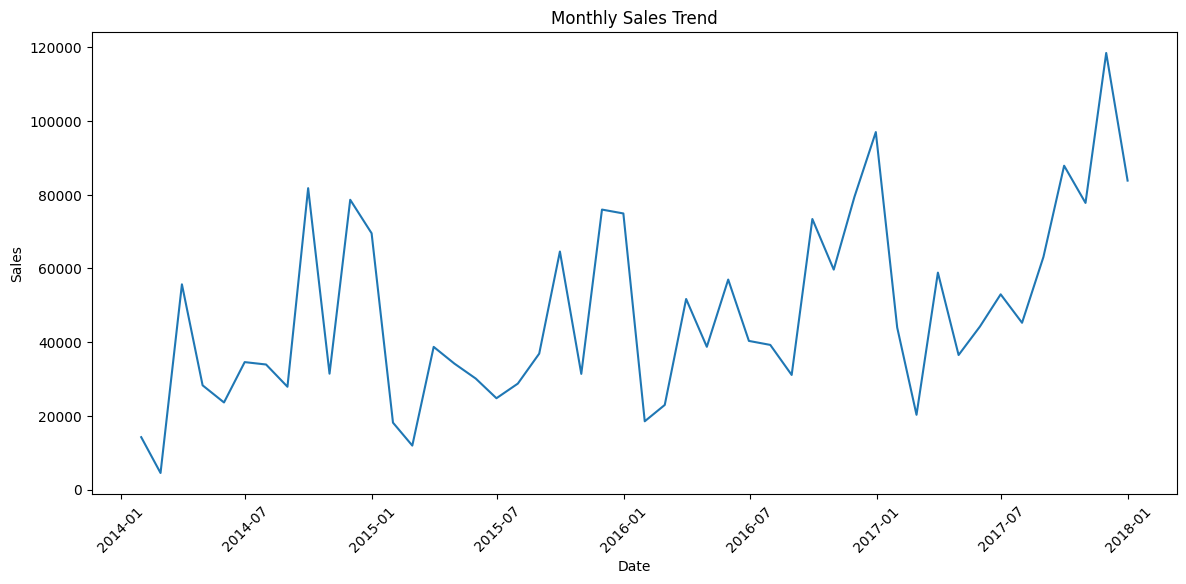

In [ ]:
# Visualize the monthly sales trend using a line chart
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

## **Analysis**

The **Monthly Sales Trend** graph shows significant fluctuations in sales over the period from **2014 to 2018**. Sales generally increase over time, with several sharp peaks and declines. The highest sales occur near the end of **2017**, reaching approximately **$118,000**, while some months record sales below **$20,000**. Overall, the trend indicates **increasing sales with strong month-to-month variability and noticeable seasonal fluctuations**.


In [ ]:
# Import the function for securely entering the API key
from getpass import getpass
# Ask for your Gemini API key without displaying it
API_KEY = getpass(
    "Enter your Gemini API Key: "
)
# Create the Gemini client using your API key
client = genai.Client(
    api_key=API_KEY
)
# Confirm that the client was created
print("Gemini client created successfully.")

Enter your Gemini API Key: ··········
Gemini client created successfully.


In [ ]:
# Define a function to understand the user's business question
def understand_question(question):
 # Create a detailed prompt for Gemini
    prompt = f"""
You are an AI Business Analyst working with a Superstore sales dataset.

Dataset columns:
{df.columns.tolist()}

Numeric metrics:
Sales, Quantity, Discount, Profit

Categorical columns:
Ship Mode, Segment, Country, City, State, Region,
Category, Sub-Category, Product Name

The user asks:

"{question}"

Your task is ONLY to understand what the user wants.

Return ONLY valid JSON.

Use this exact format:

{{
    "operation": "",
    "metric": "",
    "group_by": "",
    "n": 10
}}

Allowed operations:

total
average
minimum
maximum
count
top_n
bottom_n
group_by

Allowed metrics:

Sales
Quantity
Discount
Profit

Allowed group_by columns:

Ship Mode
Segment
Country
City
State
Region
Category
Sub-Category
Product Name

Rules:

1. Never generate Python code.
2. Never calculate the answer.
3. Never invent column names.
4. If the user asks "total sales", operation = "total", metric = "Sales".
5. If the user asks "total profit", operation = "total", metric = "Profit".
6. If the user asks "average sales", operation = "average", metric = "Sales".
7. If the user asks "sales by category", operation = "group_by", metric = "Sales", group_by = "Category".
8. If the user asks "profit by region", operation = "group_by", metric = "Profit", group_by = "Region".
9. If the user asks "top products by sales", operation = "top_n", metric = "Sales", group_by = "Product Name".
10. If the user says "highest", use top_n with n=1.
11. If the user says "lowest", use bottom_n with n=1.
12. If the number is not mentioned for top/bottom, use n=10.
"""
# Send the prompt to Gemini
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )
# Get and clean Gemini's text response
    text = response.text.strip()

    # Remove markdown JSON fences if Gemini adds them
    text = re.sub(
        r"```json",
        "",
        text,
        flags=re.IGNORECASE
    )
# Remove closing Markdown fences
    text = text.replace(
        "```",
        ""
    ).strip()

    intent = json.loads(text)
 # Return the understood question intent
    return intent

In [ ]:
# Validate the AI-generated intent
def validate_intent(intent):
# Define supported calculation operations
    allowed_operations = {
        "total",
        "average",
        "minimum",
        "maximum",
        "count",
        "top_n",
        "bottom_n",
        "group_by"
    }
# Define supported numeric metrics
    allowed_metrics = {
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    }
# Define supported dataset columns for grouping
    allowed_group_columns = {
        "Ship Mode",
        "Segment",
        "Country",
        "City",
        "State",
        "Region",
        "Category",
        "Sub-Category",
        "Product Name"
    }
# Extract values from the AI response
    operation = intent.get("operation")
    metric = intent.get("metric")
    group_by = intent.get("group_by")
# Validate the requested operation
    if operation not in allowed_operations:
        raise ValueError(
            f"Unsupported operation: {operation}"
        )
 # Validate the requested metric
    if metric and metric not in allowed_metrics:
        raise ValueError(
            f"Unsupported metric: {metric}"
        )
 # Validate the requested grouping column
    if group_by and group_by not in allowed_group_columns:
        raise ValueError(
            f"Unsupported group column: {group_by}"
        )
# Return success when every value is valid
    return True

In [ ]:
# Calculate the result based on the validated user intent
def calculate_result(intent, data):
# Extract analysis settings from the intent
    operation = intent["operation"]
    metric = intent.get("metric")
    group_by = intent.get("group_by")
    n = intent.get("n", 10)

    # -------------------------
    # TOTAL
    # -------------------------
# Calculate the total value of the selected metric
    if operation == "total":

        value = data[metric].sum()

        return {
            "type": "number",
            "operation": operation,
            "metric": metric,
            "value": float(value)
        }

    # -------------------------
    # AVERAGE
    # -------------------------
# Calculate the average value of the selected metric
    elif operation == "average":

        value = data[metric].mean()

        return {
            "type": "number",
            "operation": operation,
            "metric": metric,
            "value": float(value)
        }

    # -------------------------
    # MINIMUM
    # -------------------------
# Find the minimum value of the selected metric
    elif operation == "minimum":

        value = data[metric].min()

        return {
            "type": "number",
            "operation": operation,
            "metric": metric,
            "value": float(value)
        }

    # -------------------------
    # MAXIMUM
    # -------------------------
# Find the maximum value of the selected metric
    elif operation == "maximum":

        value = data[metric].max()

        return {
            "type": "number",
            "operation": operation,
            "metric": metric,
            "value": float(value)
        }

    # -------------------------
    # COUNT
    # -------------------------
# Count the total number of records in the dataset
    elif operation == "count":

        return {
            "type": "number",
            "operation": operation,
            "metric": "Records",
            "value": int(len(data))
        }

    # -------------------------
    # GROUP BY
    # -------------------------
# Calculate totals for each value in the selected grouping column
    elif operation == "group_by":

        result = (
            data
            .groupby(group_by)[metric]
            .sum()
            .sort_values(
                ascending=False
            )
            .reset_index()
        )
# Rename the result columns for clear display
        result.columns = [
            group_by,
            f"Total {metric}"
        ]

        return {
            "type": "table",
            "operation": operation,
            "metric": metric,
            "group_by": group_by,
            "data": result
        }

    # -------------------------
    # TOP N
    # -------------------------
# Return the top N groups based on total metric value
    elif operation == "top_n":

        n = int(n or 10)

        result = (
            data
            .groupby(group_by)[metric]
            .sum()
            .sort_values(
                ascending=False
            )
            .head(n)
            .reset_index()
        )
# Rename the result columns for clear display
        result.columns = [
            group_by,
            f"Total {metric}"
        ]

        return {
            "type": "table",
            "operation": operation,
            "metric": metric,
            "group_by": group_by,
            "data": result
        }

    # -------------------------
    # BOTTOM N
    # -------------------------
# Return the bottom N groups based on total metric value
    elif operation == "bottom_n":

        n = int(n or 10)

        result = (
            data
            .groupby(group_by)[metric]
            .sum()
            .sort_values(
                ascending=True
            )
            .head(n)
            .reset_index()
        )
# Rename the result columns for clear display
        result.columns = [
            group_by,
            f"Total {metric}"
        ]

        return {
            "type": "table",
            "operation": operation,
            "metric": metric,
            "group_by": group_by,
            "data": result
        }
# Raise an error for an unsupported analysis operation
    else:

        raise ValueError(
            f"Unsupported operation: {operation}"
        )

In [ ]:
# Format a value based on its metric type
def format_value(value, metric):
 # Format Sales and Profit as currency
    if metric in ["Sales", "Profit"]:
        return f"${value:,.2f}"
# Format Discount as a percentage
    elif metric == "Discount":
        return f"{value:.2%}"
 # Format Quantity as a number
    elif metric == "Quantity":
        return f"{value:,.2f}"
# Format other values as numbers
    else:
        return f"{value:,.2f}"

In [ ]:
# Generate a clear business answer from the calculated result
def generate_business_answer(
    question,
    intent,
    result
):
# Extract analysis details from the intent
    operation = intent["operation"]
    metric = intent.get("metric")
    group_by = intent.get("group_by")

    # --------------------------------
    # NUMBER RESULT
    # --------------------------------
# Handle results that contain a single number
    if result["type"] == "number":

# Get and format the calculated value
        value = result["value"]

        formatted_value = format_value(
            value,
            metric
        )
# Create an answer based on the requested operation
        if operation == "total":

            answer = (
                f"The total {metric.lower()} is "
                f"**{formatted_value}**."
            )

        elif operation == "average":

            answer = (
                f"The average {metric.lower()} is "
                f"**{formatted_value}**."
            )

        elif operation == "minimum":

            answer = (
                f"The minimum {metric.lower()} is "
                f"**{formatted_value}**."
            )

        elif operation == "maximum":

            answer = (
                f"The maximum {metric.lower()} is "
                f"**{formatted_value}**."
            )
# Create an answer for the total record count
        elif operation == "count":

            answer = (
                f"The dataset contains "
                f"**{int(value):,} records**."
            )
# Create a default answer for other numeric results
        else:

            answer = (
                f"The result is **{formatted_value}**."
            )

        return answer

    # --------------------------------
    # TABLE RESULT
    # --------------------------------
# Get the table returned by the analysis
    table = result["data"]
# Return a message when there are no matching records
    if table.empty:

        return "No matching results were found."
# Get the first and second column names
    first_column = table.columns[0]
    second_column = table.columns[1]
# Get the first row, representing the highest or lowest result
    top_name = table.iloc[0][first_column]
    top_value = table.iloc[0][second_column]
# Format the leading result value
    formatted_top = format_value(
        top_value,
        metric
    )
# Create an answer for grouped results
    if operation == "group_by":

        answer = (
            f"Here is the {metric.lower()} "
            f"breakdown by {group_by}.\n\n"
            f"The highest-performing {group_by.lower()} "
            f"is **{top_name}**, with "
            f"**{formatted_top}**."
        )
# Create an answer for top-N results
    elif operation == "top_n":

        answer = (
            f"The top {len(table)} "
            f"{group_by.lower()} results by "
            f"{metric.lower()} are shown below.\n\n"
            f"The highest is **{top_name}**, with "
            f"**{formatted_top}**."
        )
 # Create an answer for bottom-N results
    elif operation == "bottom_n":

        answer = (
            f"The bottom {len(table)} "
            f"{group_by.lower()} results by "
            f"{metric.lower()} are shown below.\n\n"
            f"The lowest is **{top_name}**, with "
            f"**{formatted_top}**."
        )
# Create a default answer for table results
    else:

        answer = (
            f"The highest-performing "
            f"{group_by.lower()} is **{top_name}**, "
            f"with **{formatted_top}**."
        )
# Return the final business answer
    return answer

In [ ]:
# Create a bar chart from a table result
def create_chart(result):
# Return nothing if the result is not a table
    if result["type"] != "table":
        return None
# Get the result data table
    table = result["data"]
# Select the first column for the x-axis and second for the y-axis
    x_column = table.columns[0]
    y_column = table.columns[1]
# Create a bar chart using Plotly
    fig = px.bar(
        table,
        x=x_column,
        y=y_column,
        title=f"{y_column} by {x_column}",
        text_auto=".2s"
    )
 # Add clear labels to both chart axes
    fig.update_layout(
        xaxis_title=x_column,
        yaxis_title=y_column
    )
# Return the completed chart
    return fig

In [ ]:
# Process a business question from start to finish
def ask_business_analyst(question):

    # Check whether the user entered a question
    if not question.strip():
        return {
            "success": False,
            "message": "Please enter a question.",
            "intent": None,
            "result": None,
            "chart": None
        }

    # Handle the business analysis process and possible errors
    try:

        # Understand the user's question with Gemini
        intent = understand_question(question)

        # Validate the extracted analysis intent
        validate_intent(intent)

        # Calculate the requested result using the dataset
        result = calculate_result(intent, df)

        # Generate a clear business explanation
        answer = generate_business_answer(question, intent, result)

        # Create a chart when the result is a table
        chart = create_chart(result)

        # Return the successful analysis response
        return {
            "success": True,
            "message": answer,
            "intent": intent,
            "result": result,
            "chart": chart
        }

    # Return a helpful error message if processing fails
    except Exception as e:

        return {
            "success": False,
            "message": (
                "I could not process the question.\n\n"
                f"Error: {str(e)}"
            ),
            "intent": None,
            "result": None,
            "chart": None
        }

In [ ]:
# Ask the business analyst for total sales
response = ask_business_analyst(
    "What is the total sales?"
)

# Display the answer
print(response["message"])

The total sales is **$2,297,200.86**.


In [ ]:
# Ask the business analyst for total profit
response = ask_business_analyst(
    "What is the total profit?"
)

# Display the answer
print(response["message"])

The total profit is **$286,397.02**.


In [ ]:
# Ask the business analyst for average sales
response = ask_business_analyst(
    "What is the average sales?"
)

# Display the answer
print(response["message"])

The average sales is **$229.86**.


In [ ]:
# Ask the business analyst for sales by category
response = ask_business_analyst(
    "Show me sales by category"
)

# Display the business explanation
print(response["message"])

# Display the sales-by-category table
display(response["result"]["data"])

# Display the chart if one was created
if response["chart"] is not None:
    response["chart"].show()

Here is the sales breakdown by Category.

The highest-performing category is **Technology**, with **$836,154.03**.


,Category,Total Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


In [ ]:
# Ask the business analyst for profit by region
response = ask_business_analyst(
    "Show me profit by region"
)

# Display the business explanation
print(response["message"])

# Display the profit-by-region table
display(response["result"]["data"])

# Display the chart if one was created
if response["chart"] is not None:
    response["chart"].show()

Here is the profit breakdown by Region.

The highest-performing region is **West**, with **$108,418.45**.


,Region,Total Profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


In [ ]:
# Ask the business analyst for the top 10 products by sales
response = ask_business_analyst(
    "What are the top 10 products by sales?"
)

# Display the business explanation
print(response["message"])

# Display the top-products table
display(response["result"]["data"])

# Display the chart if one was created
if response["chart"] is not None:
    response["chart"].show()

The top 10 product name results by sales are shown below.

The highest is **Canon imageCLASS 2200 Advanced Copier**, with **$61,599.82**.


,Product Name,Total Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


In [ ]:
# Ask the business analyst for the top 5 regions by profit
response = ask_business_analyst(
    "What are the top 5 regions by profit?"
)

# Display the business explanation
print(response["message"])

# Display the top-regions table
display(response["result"]["data"])

# Display the chart if one was created
if response["chart"] is not None:
    response["chart"].show()

The top 4 region results by profit are shown below.

The highest is **West**, with **$108,418.45**.


,Region,Total Profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


In [ ]:
# Ask the business analyst for the bottom 10 products by profit
response = ask_business_analyst(
    "What are the bottom 10 products by profit?"
)

# Display the business explanation
print(response["message"])

# Display the bottom-products table
display(response["result"]["data"])

# Display the chart if one was created
if response["chart"] is not None:
    response["chart"].show()

The bottom 10 product name results by profit are shown below.

The lowest is **Cubify CubeX 3D Printer Double Head Print**, with **$-8,879.97**.


,Product Name,Total Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


In [ ]:
# Ask the business analyst which category has the highest sales
response = ask_business_analyst(
    "Which category has the highest sales?"
)

# Display the business explanation
print(response["message"])

# Display the category-sales table
display(response["result"]["data"])

The top 1 category results by sales are shown below.

The highest is **Technology**, with **$836,154.03**.


,Category,Total Sales
0,Technology,836154.033


In [ ]:
# Store the business question
question = "What are the top 5 regions by profit?"

# Send the question to the business analyst
response = ask_business_analyst(question)

# Display the user's original question
print("USER QUESTION")
print(question)

# Display the analysis intent detected by Gemini
print("\nAI DETECTED INTENT")
print(json.dumps(response["intent"], indent=4))

# Display the final business answer
print("\nAI BUSINESS ANSWER")
print(response["message"])

USER QUESTION
What are the top 5 regions by profit?

AI DETECTED INTENT
{
    "operation": "top_n",
    "metric": "Profit",
    "group_by": "Region",
    "n": 5
}

AI BUSINESS ANSWER
The top 4 region results by profit are shown below.

The highest is **West**, with **$108,418.45**.


In [ ]:
# Display the AI Business Analyst welcome message
print("🤖 AI Business Analyst")
print("=" * 50)
print("Type 'exit' to stop.")

# Keep accepting questions until the user exits
while True:

    # Ask the user to enter a business question
    question = input("\nYou: ")

    # Stop the program when the user types "exit"
    if question.lower().strip() == "exit":
        print("AI Assistant stopped.")
        break

    # Skip empty questions
    if not question.strip():
        continue

    # Send the question to the business analyst
    response = ask_business_analyst(question)

    # Display the AI-generated business answer
    print("\n🤖 AI Business Analyst:")
    print(response["message"])

    # Display table and chart results when the analysis succeeds
    if response["success"]:

        # Get the calculated result
        result = response["result"]

        # Display the result table when available
        if result["type"] == "table":
            display(result["data"])

        # Display the chart when available
        if response["chart"] is not None:
            response["chart"].show()

🤖 AI Business Analyst
Type 'exit' to stop.

You: What are the bottom 5 products by sales?

🤖 AI Business Analyst:
The bottom 5 product name results by sales are shown below.

The lowest is **Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac**, with **$1.62**.


,Product Name,Total Sales
0,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624
1,Avery 5,5.760
2,Xerox 20,6.480
3,Grip Seal Envelopes,7.072
4,Avery Hi-Liter Pen Style Six-Color Fluorescent...,7.700



You: What is the average discount?

🤖 AI Business Analyst:
The average discount is **15.62%**.

You: exit
AI Assistant stopped.


# *Key Findings*

- *Developed an AI Business Analyst Assistant using Gemini for question understanding, Pandas for calculations, and Plotly for charts.*

- *The system converts normal business questions into validated analysis tasks such as total, average, group-by, top-N, and bottom-N.*

- *The Superstore dataset contains 9,994 records and 21 columns, with no missing values or duplicate rows.*

- *Overall business performance: total sales were*  **$2.30 million, total profit was $286,397**, *and average sales per record were* **$229.86**.

- ***Technology*** *was the best category, generating the highest sales* (**$836,154) and profit ($145,455**); *Furniture had strong sales but much lower profit.*

- *The top-selling product was the* ***Canon imageCLASS 2200 Advanced Copier***, *while the* ***Cubify CubeX 3D Printer Double Head Print*** *created the largest loss.*

*In conclusion, the AI-Powered Business Analyst Assistant provides a practical way to analyze Superstore sales data through natural-language questions.* *Gemini interprets the user’s request, validation ensures only valid dataset fields and operations are used, Pandas performs the actual calculation, and Plotly creates visual charts for grouped results. The dataset was clean, with 9,994 records and no missing or duplicate values*. *The* *analysis showed total* *sales of* $2.30 million and total profit of $286,397, *with Technology and the West region as the leading contributors.* *However, Furniture’s lower profit relative to its sales and highly loss-making products such as the Cubify CubeX printer show where pricing, discounts, and product costs should be reviewed. Overall, the project demonstrates a reliable and user-friendly approach for turning raw sales data into clear business insights*.